In questo notebook vengono analizzate staticamente le risposte degli utenti sulle rispetto le 4 popolazioni differenti di task planning confrontati. In particolare, viene eseguito il test di Kruskal-Wallis per il confronto delle 4 (n in general) popolazioni differenti (per verificare che vi sia una differenza statistica tra in almeno una popolazione). Invece, il test di Mann–Whitney–Wilcoxon per il confronto su una scala di Likert di 2 popolazioni differenti (analizzate a coppie).  

In [2]:
!pip install pingouin
!pip install openpyxl
!pip install Jinja2

Defaulting to user installation because normal site-packages is not writeable
  Using cached pandas-2.2.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.0 MB)
  Attempting uninstall: pandas
    Found existing installation: pandas 1.5.3
    Uninstalling pandas-1.5.3:
      Successfully uninstalled pandas-1.5.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tts 0.22.0 requires numpy==1.22.0; python_version <= "3.10", but you have numpy 1.26.4 which is incompatible.
tts 0.22.0 requires pandas<2.0,>=1.4, but you have pandas 2.2.2 which is incompatible.
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


/tmp/ipykernel_20676/2566505090.py:104: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  test_result_p_value.loc[question_name] = None
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_20676/2566505090.py:104: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  test_result_p_value.loc[question_name] = None
/tmp/ipykernel_20676/2566505090.py:104: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  test_result_p_value.loc[question_name] = None
No artists with labels found to put in legend.  Note that artists whose label start 

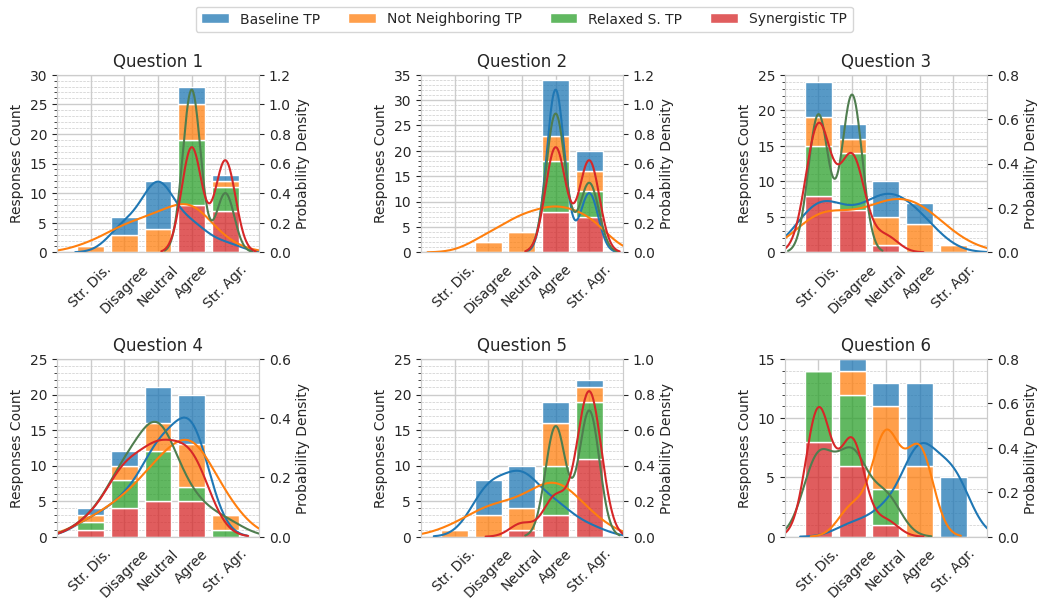

,Method C VS Method A,Method C VS Method B,Method D VS Method A,Method D VS Method B,Statistical Differences Between Methods,p-value (K.-W. Test)
Question 1: I am satisfied with the coexistence with the robot to execute the process.,2.3e-04,2.2e-03,1.1e-04,6.5e-04,True,1.2e-05
Question 2: I felt safe when working with the robot.,7.0e-01,9.1e-02,2.6e-01,3.8e-02,False,1.1e-01
Question 3: I felt that I was getting too close to the robot to perform my tasks.,3.9e-02,1.1e-02,3.9e-02,1.1e-02,True,1.1e-02
Question 4: Idle times bother me.,2.3e-01,1.3e-01,4.0e-01,2.1e-01,False,3.5e-01
Question 5: The coexistence with the robot during the execution of the process was fluent.,8.6e-05,2.1e-03,5.9e-05,7.1e-04,True,5.4e-06
Question 6: The robot often stopped because you are in the area near the robot,1.2e-05,1.1e-04,4.8e-06,1.5e-05,True,1.2e-08


,Method A (Median),Method A (Skew),Method B (Median),Method B (Skew),Method C (Median),Method C (Skew),Method D (Median),Method D (Skew)
I am satisfied with the coexistence with the robot to execute the process.,3.0,0.578805,3.0,-0.452434,4.0,1.176354,4.0,0.148961
I felt safe when working with the robot.,4.0,1.176354,4.0,-0.281962,4.0,0.788227,4.0,0.148961
I felt that I was getting too close to the robot to perform my tasks.,3.0,-0.023882,3.0,-0.06134,2.0,-0.148961,1.0,0.802288
Idle times bother me.,3.0,-1.044103,4.0,-0.589391,3.0,0.299355,3.0,-0.409237
The coexistence with the robot during the execution of the process was fluent.,3.0,0.623148,4.0,-0.451439,5.0,-0.148961,5.0,-1.791551
The robot often stopped because you are in the area near the robot,4.0,-0.858774,3.0,-0.433026,2.0,0.383042,1.0,0.802288


In [17]:
from scipy import stats
import pandas as pd
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import math

MAPPING_SCALE = {"Strongly Disagree": 1,
                 "Disagree": 2,
                 "Neither Agree nor Disagree": 3,
                 "Agree": 4,
                 "Strongly Agree": 5,
                 "Poor": 1,
                 "Bad": 2,
                 "Neutral": 3,
                 "Good": 4,
                 "Excellent": 5}

METHODS_TO_COMPARE = {"Method A":"Baseline TP",
                      "Method B":"Not Neighboring TP",
                      "Method C":"Relaxed S. TP",
                      "Method D":"Synergistic TP"}

COUPLING_OF_METHODS_TO_COMPARE = [("Method C", "Method A"),
                                  ("Method C", "Method B"),
                                  ("Method D", "Method A"),
                                  ("Method D", "Method B")]

METHOD_TO_DESATURATE = METHODS_TO_COMPARE["Method C"]

DIFFERENCES = "Statistical Differences Between Methods"

INTERESTED_QUESTION = ["I felt safe when working with the robot.",
                       "I felt that I was getting too close to the robot to perform my tasks.",
                       "The robot often stopped because you are in the area near the robot",
                       "The coexistence with the robot during the execution of the process was fluent.",
                       "I am satisfied with the coexistence with the robot to execute the process.",
                       "Idle times bother me."]

MEAN_COLUMN_FORMAT = "{} (Median)"
STD_COLUMN_FORMAT = "{} (Skew)"
ANALYSE_ALL_QUESTION = False
TEST_COLUMN_NAME = "p-value (K.-W. Test)"
PATH = "https://github.com/JRL-CARI-CNR-UNIBS/hrc_case_study/raw/e_waste_case_study/hrc_case_study_results/Questionnaire/TPHA_Questionnaire.xlsx"

BOXPLOT = False
VERTICAL = False

if BOXPLOT:
  sns.set_theme()
else:
  sns.set_style("whitegrid")

def get_questions(columns_name, method_to_compare):
  questions = set()
  for column_name in questionnaire_responses.columns:
    if any([method in column_name for method in method_to_compare]):
      matched_string = re.search(r'\[([^]]+)\]', column_name)
      if matched_string:
        between_square_brack = matched_string.group(1)
        questions.add(between_square_brack)
      else:
        raise Exception("No [] detected")
    else:
      pass
  return questions

questionnaire_responses = pd.read_excel(PATH)

questionnaire_responses = questionnaire_responses.replace(MAPPING_SCALE)

questions = get_questions(questionnaire_responses.columns, METHODS_TO_COMPARE.keys())

n_user = len(questionnaire_responses.index)
question_user_tuple = []
question_correspondence = dict()

if not ANALYSE_ALL_QUESTION:
  if VERTICAL:
    fig, axs = plt.subplots(3, 2, figsize=(8, 13), gridspec_kw={'hspace': 0.4, 'wspace': 1})
  else:
    fig, axs = plt.subplots(2, 3, figsize=(12, 6), gridspec_kw={'hspace': 0.6, 'wspace': 0.8, 'width_ratios': [3, 3, 3]})

question_id = 0

test_result_p_value = pd.DataFrame(columns=[f"{method_1} VS {method_2}" for (method_1,method_2) in COUPLING_OF_METHODS_TO_COMPARE])
test_result_p_value[DIFFERENCES] = None
test_result_p_value[TEST_COLUMN_NAME] = None

column_names = [MEAN_COLUMN_FORMAT.format(method) for method in METHODS_TO_COMPARE.keys()] + \
               [STD_COLUMN_FORMAT.format(method) for method in METHODS_TO_COMPARE.keys()]

stats_results_comparison = pd.DataFrame(columns=column_names)
questions = sorted(questions)

selected_question = [question for question in questions if (question in INTERESTED_QUESTION) or (ANALYSE_ALL_QUESTION)]

for id, question in enumerate(questions):
  question_name = f"Question {question_id + 1}: {question}"
  if (question not in INTERESTED_QUESTION) and not(ANALYSE_ALL_QUESTION):
    continue
  test_result_p_value.loc[question_name] = None

  single_question_pd = questionnaire_responses.filter(like=question)
  single_question_pd_sorted = single_question_pd.reindex(sorted(single_question_pd.columns), axis=1)

  int_method = single_question_pd.columns[0]

  question_correspondence[f"Question {id}"] = question

  questions_user_array = np.array([f"Question {id}" for user in range(0,n_user)])
  users_array = np.array([f"User  {user}" for user in range(0,n_user)])

  question_user_list = [questions_user_array, users_array]
  df = pd.DataFrame(single_question_pd_sorted.to_numpy(), index=question_user_list, columns = METHODS_TO_COMPARE.keys())

  statistic, p_value = stats.kruskal(*[df.loc[:,method] for method in METHODS_TO_COMPARE.keys()])

  test_result_p_value.loc[question_name,TEST_COLUMN_NAME] = p_value
  if p_value < 0.05:
    test_result_p_value.loc[question_name,DIFFERENCES] = True
  else:
    test_result_p_value.loc[question_name,DIFFERENCES] = False

  methods_answer_mean = df.median()
  methods_answer_std = df.skew()
  for method in METHODS_TO_COMPARE.keys():
    stats_results_comparison.loc[question,MEAN_COLUMN_FORMAT.format(method)] = methods_answer_mean[method]
    stats_results_comparison.loc[question,STD_COLUMN_FORMAT.format(method)] = methods_answer_std[method]

  stats_results_pd = pd.DataFrame({"Median":methods_answer_mean,"Skew": methods_answer_std})

  for couple_of_methods in COUPLING_OF_METHODS_TO_COMPARE:
    method_1 = couple_of_methods[0]
    method_2 = couple_of_methods[1]
    statistic, p_value = stats.kruskal(df.loc[:,method_1],df.loc[:,method_2])
    test_result_p_value.loc[question_name,f"{method_1} VS {method_2}"] = p_value

  if not(ANALYSE_ALL_QUESTION):
    if VERTICAL:
      row_index = question_id // 2
      col_index = question_id % 2
    else:
      row_index = question_id // 3
      col_index = question_id % 3

    binwidth = 1
    binrange = 5

    df = df.rename(columns = METHODS_TO_COMPARE)
    if BOXPLOT:
      sns.boxplot(data=df.melt(value_name='Risposta'), x='Risposta', y='variable', ax=axs[row_index, col_index])
      axs[row_index, col_index].set_xlabel('')
      axs[row_index, col_index].set_ylabel('')
    else:
      sns.histplot(data=df, ax=axs[row_index, col_index], bins=8, multiple="stack", discrete = True, shrink=0.8, color=sns.color_palette())
      axs[row_index, col_index].set_ylabel("Responses Count")

      ax2 = axs[row_index, col_index].twinx()

      custom_palette = sns.color_palette()
      color_desaturated = [sns.desaturate(color,0.4) for color in custom_palette]

      for col, color, color_desat in zip(df.columns, custom_palette, color_desaturated):
        if col == METHOD_TO_DESATURATE:
          sns.kdeplot(df[col], ax=ax2, color=color_desat)
        else:
          sns.kdeplot(df[col], ax=ax2, color=color)
        
      ax2.set_ylabel("Probability Density")
      ax2.grid(None)

      axs[row_index, col_index].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
      ax2.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
      yticks = np.arange(0, ax2.get_yticks()[-1] + 0.2, 0.2)
      ax2.set_yticks(yticks)

    axs[row_index, col_index].grid(True, which='major', linestyle='-', linewidth=1)
    axs[row_index, col_index].grid(True, which='minor', linestyle='--', linewidth=0.5)
    axs[row_index, col_index].yaxis.set_major_locator(plt.MultipleLocator(5))
    axs[row_index, col_index].yaxis.set_minor_locator(plt.MultipleLocator(1))
    tmp = df.apply(pd.Series.value_counts)
    ymax = math.ceil(max(tmp.sum(1)) / 5) * 5
    axs[row_index, col_index].set_ylim(0, ymax)

    axs[row_index, col_index].set_title(f"Question {question_id+1}")
    axs[row_index, col_index].set_xticks([1, 2, 3, 4, 5])
    axs[row_index, col_index].set_xlim(0, 6)
    axs[row_index, col_index].set_xticklabels(['Str. Dis.', 'Disagree', 'Neutral', 'Agree', 'Str. Agr.'], rotation=45)

    legend =  axs[row_index, col_index].get_legend()
    handle = legend.legend_handles

    axs[row_index, col_index].legend().set_visible(False)

  question_id += 1

if not(BOXPLOT):
  if VERTICAL:
    pass
  else:
    plt.figlegend(handle, df.columns, ncol=len(df.columns), loc="upper center")

plt.show()

def highlight(val):
    if isinstance(val,bool):
      if val:
        background_color = 'background-color: rgba(0, 255, 0, 0.2)'
      else:
        background_color = 'background-color: rgba(255, 0, 0, 0.2)'
    else:
      if val < 0.05:
          background_color = 'background-color: rgba(0, 255, 0, 0.2)'
      else:
          background_color = 'background-color: rgba(255, 0, 0, 0.2)'
    return background_color

test_result_p_value = test_result_p_value.style.applymap(highlight).format({col: '{:.1e}' for col, dtype in test_result_p_value.dtypes.items() if dtype in ['float64', 'int64']})


stats_results_comparison = stats_results_comparison.reindex(sorted(stats_results_comparison.columns), axis=1)
styled_df = df.style.applymap(highlight)

display(test_result_p_value)
display(stats_results_comparison)
